In [1]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

In [11]:
from pyqit.data.datamodule import DataModule

dm = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

In [12]:
from pyqit.ansatzes.sel import SELAnsatz
from pyqit.core.embeddings import AngleEmbedding
from pyqit.core.trainer import Trainer
from pyqit.models.vqc import VQCClassifier

# Initialize the VQC
model = VQCClassifier(
    n_qubits=4,
    n_layers=3,
    n_classes=2,
    ansatz=SELAnsatz,
    encoder=AngleEmbedding,
    backend="pennylane",
)

# Spin up the Trainer
trainer = Trainer(
    backend_type="pennylane", max_epochs=15, learning_rate=0.05, loss_fn="cross_entropy"
)

history = trainer.fit(model, datamodule=dm)

[Trainer] PennyLane backend | 15 epochs | lr=0.05
  epoch    0  loss=0.7640  acc=0.429  val_loss=0.6077  val_acc=0.633  [2.2s]
  epoch    1  loss=0.6837  acc=0.536  val_loss=0.6522  val_acc=0.600  [1.6s]
  epoch    2  loss=0.6763  acc=0.571  val_loss=0.7121  val_acc=0.567  [1.5s]
  epoch    3  loss=0.6883  acc=0.536  val_loss=0.7308  val_acc=0.533  [1.5s]
  epoch    4  loss=0.6885  acc=0.500  val_loss=0.7101  val_acc=0.400  [1.4s]
  epoch    5  loss=0.6826  acc=0.557  val_loss=0.6777  val_acc=0.667  [1.4s]
  epoch    6  loss=0.6875  acc=0.543  val_loss=0.6560  val_acc=0.667  [1.4s]
  epoch    7  loss=0.6808  acc=0.629  val_loss=0.6246  val_acc=0.733  [1.4s]
  epoch    8  loss=0.6566  acc=0.700  val_loss=0.5867  val_acc=0.800  [1.4s]
  epoch    9  loss=0.6328  acc=0.664  val_loss=0.5778  val_acc=0.833  [1.6s]
  epoch   10  loss=0.6237  acc=0.707  val_loss=0.5906  val_acc=0.833  [1.4s]
  epoch   11  loss=0.6256  acc=0.657  val_loss=0.6045  val_acc=0.800  [1.4s]
  epoch   12  loss=0.6304 

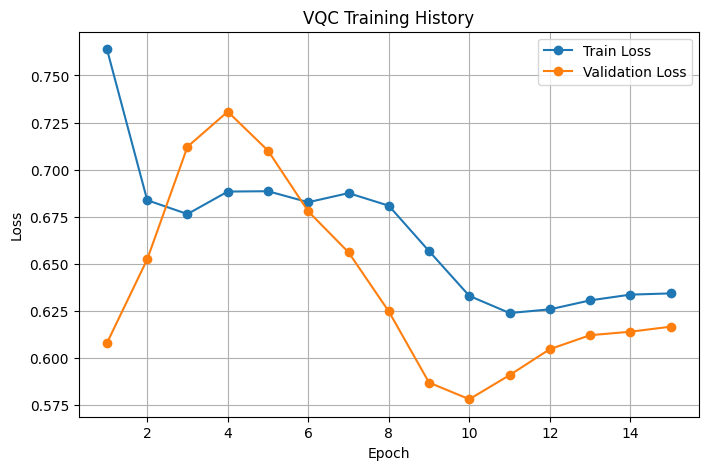

In [13]:
import matplotlib.pyplot as plt

# Extract metrics from the PyQit history object
train_loss = history.as_dict()["train_loss"]
val_loss = history.as_dict()["val_loss"]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, val_loss, label="Validation Loss", marker="o")
plt.title("VQC Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Standalone VQC Test Accuracy: 53.33%


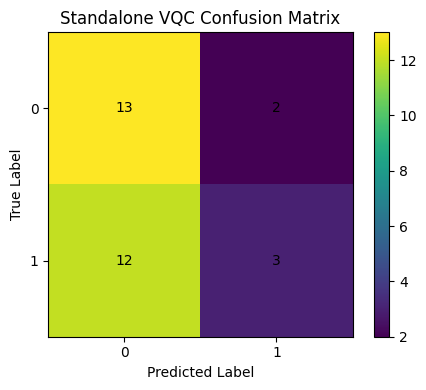

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on the holdout Test Set
predictions = trainer.predict(model, datamodule=dm, return_format="numpy")
actuals = dm.y_test.astype(int)

# Calculate Accuracy
acc = accuracy_score(actuals, predictions)
print(f"Standalone VQC Test Accuracy: {acc * 100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Standalone VQC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Add ticks
plt.xticks(np.arange(cm.shape[1]))
plt.yticks(np.arange(cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()

# Using `QuantumPipeline`

In [15]:
dm_new = DataModule(
    X=X,
    y=y,
    normalize="minmax",
    batch_size=16,
    split=(0.7, 0.15, 0.15),
    seed=42,
)

In [24]:
print("\n--- Pre-training the Backbone ---")
backbone = VQCClassifier(n_qubits=4, n_layers=4, backend="torch")

pre_trainer = Trainer(backend_type="torch", max_epochs=10, learning_rate=0.1)
pre_trainer.fit(backbone, dm_new)


--- Pre-training the Backbone ---
[Trainer] Torch backend | 10 epochs | lr=0.1


/home/aryan/PyQit/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


  epoch    0  loss=0.2229  acc=0.800  val_loss=0.2080  val_acc=0.600  [0.7s]
  epoch    1  loss=0.1843  acc=0.757  val_loss=0.1782  val_acc=0.733  [0.6s]
  epoch    2  loss=0.1833  acc=0.814  val_loss=0.1873  val_acc=0.667  [0.3s]
  epoch    3  loss=0.1769  acc=0.821  val_loss=0.2086  val_acc=0.633  [0.3s]
  epoch    4  loss=0.1723  acc=0.807  val_loss=0.1964  val_acc=0.600  [0.3s]
  epoch    5  loss=0.1725  acc=0.843  val_loss=0.1783  val_acc=0.733  [0.3s]
  epoch    6  loss=0.1757  acc=0.850  val_loss=0.1913  val_acc=0.633  [0.3s]
  epoch    7  loss=0.1737  acc=0.807  val_loss=0.1906  val_acc=0.633  [0.3s]
  epoch    8  loss=0.1720  acc=0.814  val_loss=0.2042  val_acc=0.567  [0.3s]
  epoch    9  loss=0.1639  acc=0.779  val_loss=0.1684  val_acc=0.733  [0.3s]
[Trainer] Training complete.


TrainingHistory(epochs=10, best_val_loss=0.1684 @ epoch 9)

In [28]:
from pyqit.core.pipeline import PipelineStage, QuantumPipeline

# Stage 1: The "Pre-trained" Backbone (Frozen)
backbone = VQCClassifier(n_qubits=4, n_layers=4, backend="torch")
stage_1 = PipelineStage(backbone, name="feature_extractor", trainable=False)

# Stage 2: The Active Head (Trainable)
head = VQCClassifier(n_qubits=4, n_layers=1, backend="torch")
stage_2 = PipelineStage(head, name="classifier", trainable=True)

# Combine them into a Pipeline
pipeline = QuantumPipeline([stage_1, stage_2], mode="sequential")
trainer_new = Trainer(
    backend_type="pennylane", max_epochs=10, learning_rate=0.05, loss_fn="cross_entropy"
)

print("\nTraining Quantum Pipeline...")
pipeline.fit(datamodule=dm_new, trainers=trainer_new, fit_mode="frozen_backbone")


Training Quantum Pipeline...
[Trainer] PennyLane backend | 10 epochs | lr=0.05
  epoch    0  loss=0.7189  acc=0.479  val_loss=0.6797  val_acc=0.600  [0.6s]
  epoch    1  loss=0.6963  acc=0.479  val_loss=0.6925  val_acc=0.600  [0.6s]
  epoch    2  loss=0.6975  acc=0.521  val_loss=0.7016  val_acc=0.400  [0.6s]
  epoch    3  loss=0.6927  acc=0.521  val_loss=0.7027  val_acc=0.400  [0.6s]
  epoch    4  loss=0.6943  acc=0.521  val_loss=0.7012  val_acc=0.400  [0.6s]
  epoch    5  loss=0.6910  acc=0.521  val_loss=0.7006  val_acc=0.400  [0.6s]
  epoch    6  loss=0.6898  acc=0.521  val_loss=0.7007  val_acc=0.400  [0.6s]
  epoch    7  loss=0.6917  acc=0.521  val_loss=0.7030  val_acc=0.400  [0.6s]
  epoch    8  loss=0.6925  acc=0.521  val_loss=0.7041  val_acc=0.400  [0.6s]
  epoch    9  loss=0.6953  acc=0.521  val_loss=0.7052  val_acc=0.400  [0.6s]
[Trainer] Training complete.


QuantumPipeline(mode=sequential)
  ('feature_extractor', Stage(feature_extractor [frozen]))
  ('classifier', Stage(classifier))

Pipeline Test Accuracy: 50.00%


/home/aryan/PyQit/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/home/aryan/PyQit/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'autograd', 'torch'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(


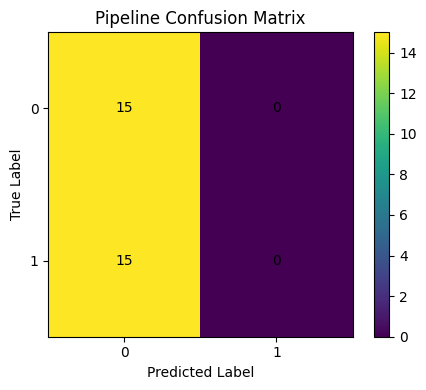

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

pipeline_preds = pipeline.predict(
    X=dm.X_test, batch_size=16, backend="torch", return_format="numpy"
)

pipe_acc = accuracy_score(actuals, pipeline_preds)
print(f"Pipeline Test Accuracy: {pipe_acc * 100:.2f}%")

pipe_cm = confusion_matrix(actuals, pipeline_preds)

plt.figure(figsize=(5, 4))
plt.imshow(pipe_cm)
plt.title("Pipeline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(pipe_cm.shape[0]):
    for j in range(pipe_cm.shape[1]):
        plt.text(j, i, pipe_cm[i, j], ha="center", va="center")

plt.xticks(np.arange(pipe_cm.shape[1]))
plt.yticks(np.arange(pipe_cm.shape[0]))

plt.colorbar()
plt.tight_layout()
plt.show()